In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
hotel_data = pd.read_csv(r'../data/raw/hotel_bookings.csv')

In [3]:
hotel_data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
# checking shape (no of rows and columns)
hotel_data.shape

(119390, 32)

In [5]:
# checking values of each columns
for col in hotel_data.columns :
    print(f'{col} \n has values = \n')
    print(hotel_data[col].value_counts())

hotel 
 has values = 

hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64
is_canceled 
 has values = 

is_canceled
0    75166
1    44224
Name: count, dtype: int64
lead_time 
 has values = 

lead_time
0      6345
1      3460
2      2069
3      1816
4      1715
       ... 
532       1
387       1
458       1
380       1
463       1
Name: count, Length: 479, dtype: int64
arrival_date_year 
 has values = 

arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64
arrival_date_month 
 has values = 

arrival_date_month
August       13877
July         12661
May          11791
October      11160
April        11089
June         10939
September    10508
March         9794
February      8068
November      6794
December      6780
January       5929
Name: count, dtype: int64
arrival_date_week_number 
 has values = 

arrival_date_week_number
33    3580
30    3087
32    3045
34    3040
18    2926
21    2854
28    2853
17    2805
20    2785
29    27

In [6]:
# checking data types of each column 
hotel_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [7]:
# checking null value columns 
for col in hotel_data.columns :
    print(f'{col} has : {hotel_data[col].isnull().sum()} null values ')

hotel has : 0 null values 
is_canceled has : 0 null values 
lead_time has : 0 null values 
arrival_date_year has : 0 null values 
arrival_date_month has : 0 null values 
arrival_date_week_number has : 0 null values 
arrival_date_day_of_month has : 0 null values 
stays_in_weekend_nights has : 0 null values 
stays_in_week_nights has : 0 null values 
adults has : 0 null values 
children has : 4 null values 
babies has : 0 null values 
meal has : 0 null values 
country has : 488 null values 
market_segment has : 0 null values 
distribution_channel has : 0 null values 
is_repeated_guest has : 0 null values 
previous_cancellations has : 0 null values 
previous_bookings_not_canceled has : 0 null values 
reserved_room_type has : 0 null values 
assigned_room_type has : 0 null values 
booking_changes has : 0 null values 
deposit_type has : 0 null values 
agent has : 16340 null values 
company has : 112593 null values 
days_in_waiting_list has : 0 null values 
customer_type has : 0 null values 
a

In [8]:
# checking duplicate values
# Count how many total duplicate rows exist
print("Total duplicated rows:", hotel_data.duplicated().sum())
# Show all duplicate rows (keeping all occurrences)
duplicate_rows = hotel_data[hotel_data.duplicated(keep=False)].sort_values(by=list(hotel_data.columns[:]))
duplicate_rows.head(10)

Total duplicated rows: 31994


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
40772,City Hotel,0,0,2015,August,32,7,0,2,2,...,No Deposit,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2015-08-09
40802,City Hotel,0,0,2015,August,32,7,0,2,2,...,No Deposit,14.0,NaN,0,Transient,75.0,0,1,Check-Out,2015-08-09
40821,City Hotel,0,0,2015,August,32,8,0,1,2,...,No Deposit,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09
40838,City Hotel,0,0,2015,August,32,8,0,1,2,...,No Deposit,9.0,NaN,0,Transient,89.0,0,1,Check-Out,2015-08-09
76792,City Hotel,0,0,2015,August,33,10,1,0,2,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
76793,City Hotel,0,0,2015,August,33,10,1,0,2,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
76794,City Hotel,0,0,2015,August,33,10,1,0,2,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-08-11
41067,City Hotel,0,0,2015,August,33,11,0,1,1,...,No Deposit,NaN,38.0,0,Transient-Party,88.0,0,0,Check-Out,2015-08-12
41073,City Hotel,0,0,2015,August,33,11,0,1,1,...,No Deposit,NaN,38.0,0,Transient-Party,88.0,0,0,Check-Out,2015-08-12
41071,City Hotel,0,0,2015,August,33,11,0,1,2,...,No Deposit,NaN,NaN,0,Transient,80.0,0,0,Check-Out,2015-08-12


In [9]:
# getting cat columns
cat_columns = hotel_data.select_dtypes(include = ['category' , 'object' , 'str']).columns.tolist()
cat_columns

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type',
 'reservation_status',
 'reservation_status_date']

In [10]:
# getting numerical cols
num_columns = hotel_data.select_dtypes(include = ['int64' , 'float64']).columns.tolist()
num_columns

['is_canceled',
 'lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'agent',
 'company',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [11]:
# checking describtion of each numerical col
hotel_data.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [12]:
# checking skewness of num_columns
for col in num_columns:
    print(f'Skewness of {col} is {hotel_data[col].skew()}')

Skewness of is_canceled is 0.5366783893964282
Skewness of lead_time is 1.3465498727254264
Skewness of arrival_date_year is -0.23258325181277467
Skewness of arrival_date_week_number is -0.010014326041540761
Skewness of arrival_date_day_of_month is -0.002000453978614959
Skewness of stays_in_weekend_nights is 1.3800464497062852
Skewness of stays_in_week_nights is 2.8622492420671244
Skewness of adults is 18.317804759206098
Skewness of children is 4.11258954232252
Skewness of babies is 24.646544829663092
Skewness of is_repeated_guest is 5.326315335062105
Skewness of previous_cancellations is 24.458048723119287
Skewness of previous_bookings_not_canceled is 23.539799952843467
Skewness of booking_changes is 6.000270054409322
Skewness of agent is 1.0893856361088765
Skewness of company is 0.6015996673442214
Skewness of days_in_waiting_list is 11.944353446438395
Skewness of adr is 10.53021398218952
Skewness of required_car_parking_spaces is 4.163233237874087
Skewness of total_of_special_requests 

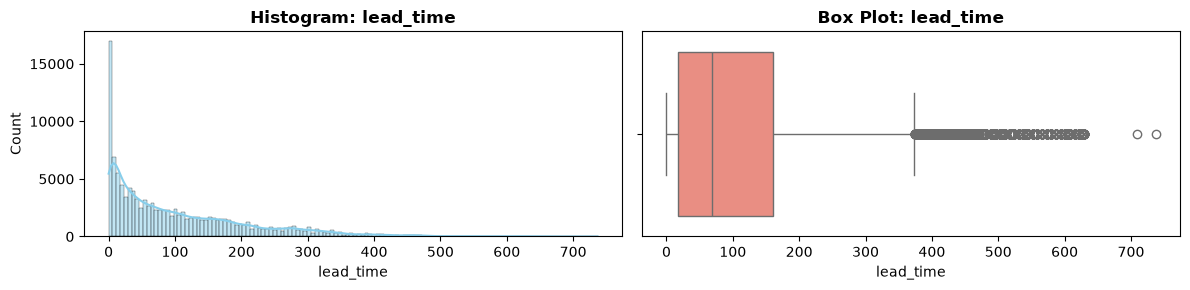

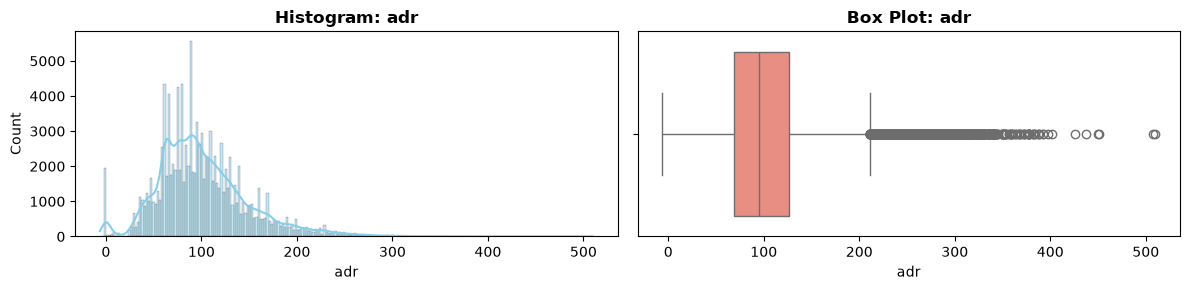

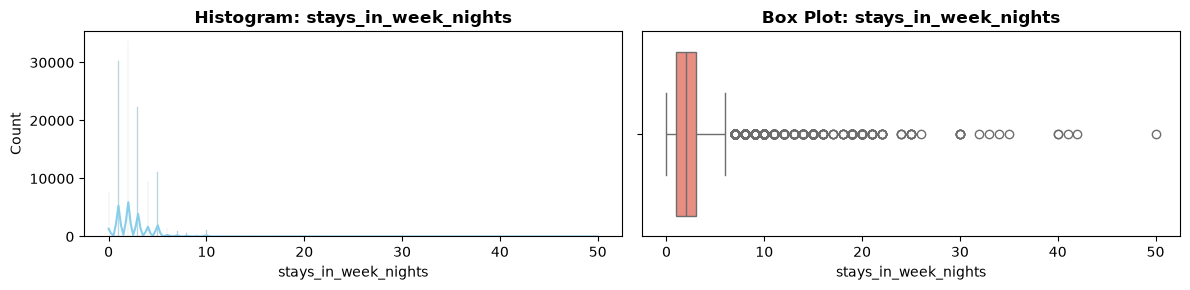

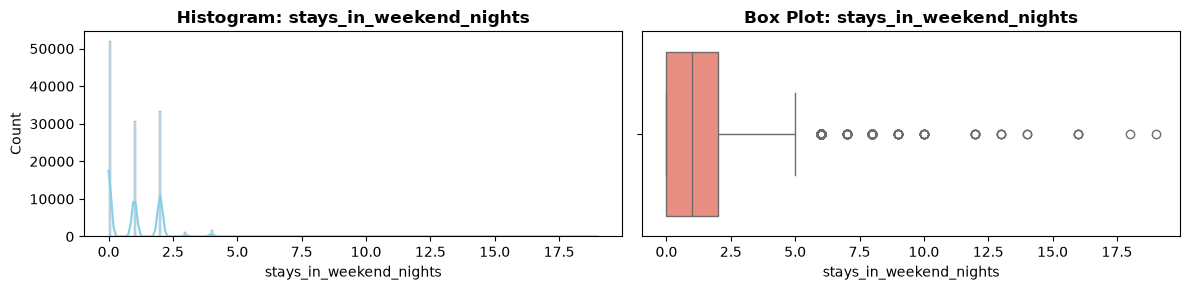

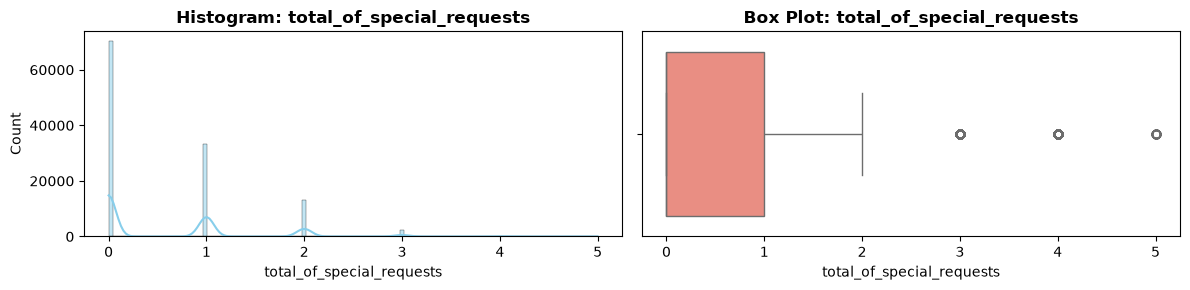

In [13]:
# plotting numerical cols graph
# 1. continous numerical columns
continuous_cols = [
    'lead_time', 
    'adr', 
    'stays_in_week_nights', 
    'stays_in_weekend_nights', 
    'total_of_special_requests'
]

for col in continuous_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    
    # Temporarily trim extreme adr outlier for clean visualization
    df_plot = hotel_data[hotel_data['adr'] < 1000] if col == 'adr' else hotel_data
    
    sns.histplot(data=df_plot, x=col, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Histogram: {col}', fontweight='bold')
    
    sns.boxplot(data=df_plot, x=col, ax=axes[1], color='salmon')
    axes[1].set_title(f'Box Plot: {col}', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

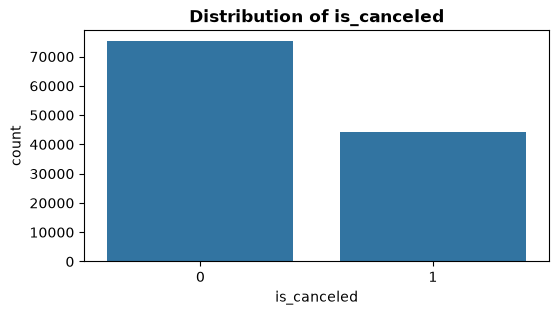

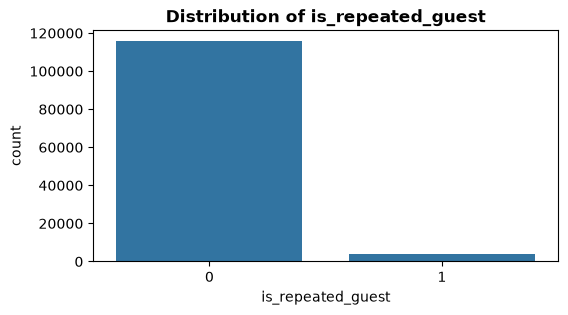

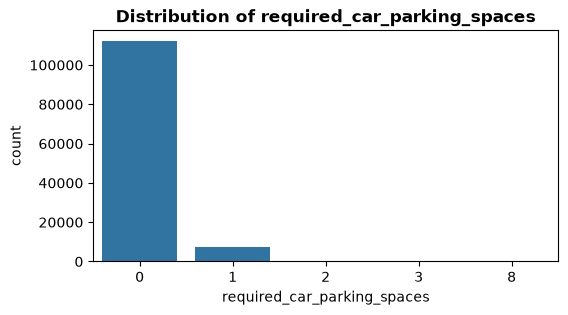

In [14]:
# 2. on discrete and binary cols 
binary_and_discrete = ['is_canceled', 'is_repeated_guest', 'required_car_parking_spaces']

for col in binary_and_discrete:
    plt.figure(figsize=(6, 3))
    sns.countplot(data=hotel_data, x=col)
    plt.title(f'Distribution of {col}', fontweight='bold')
    plt.show()

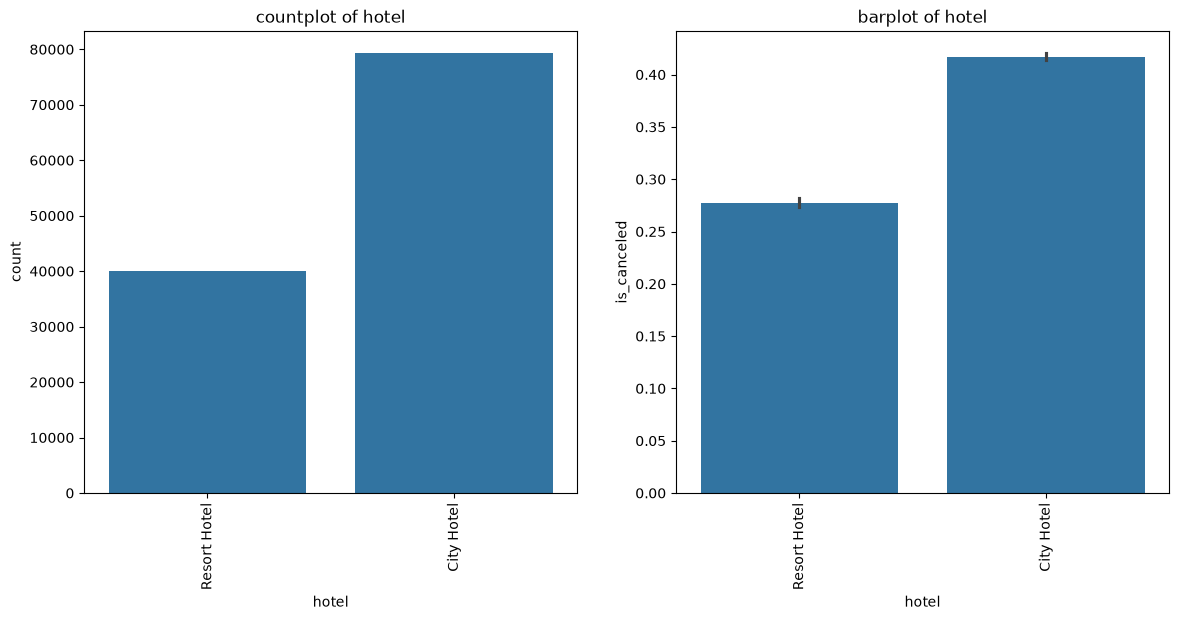

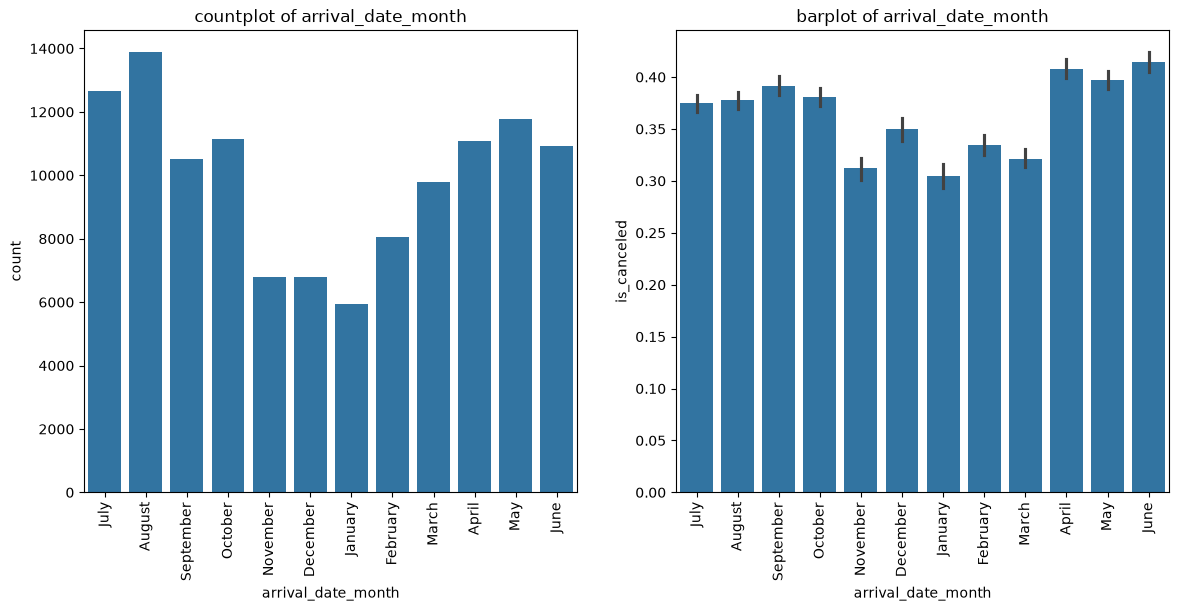

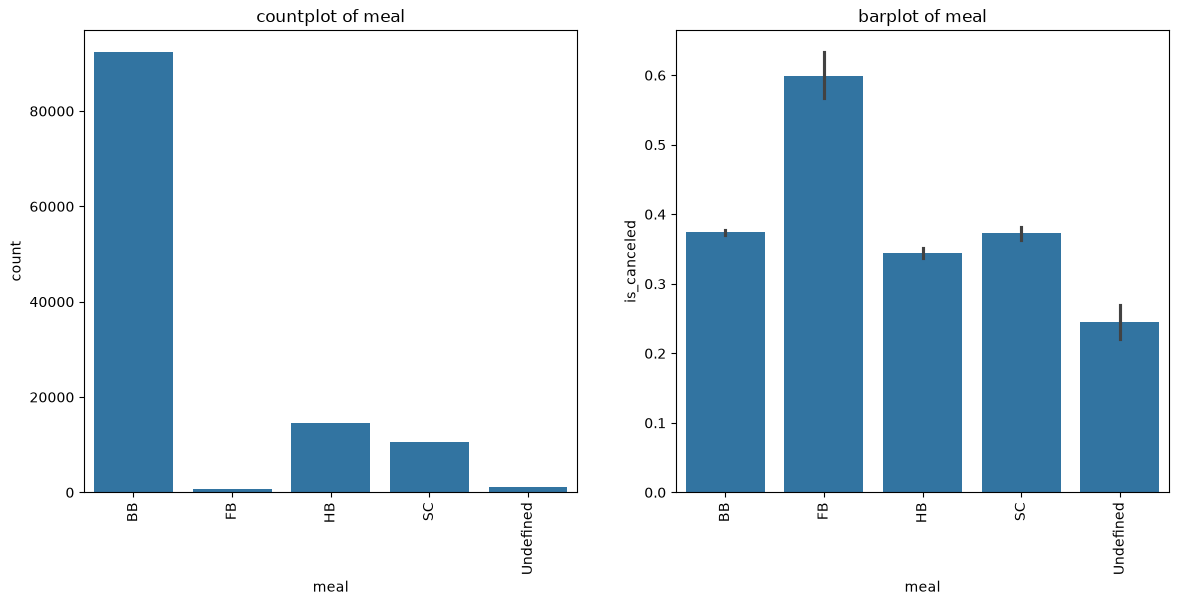

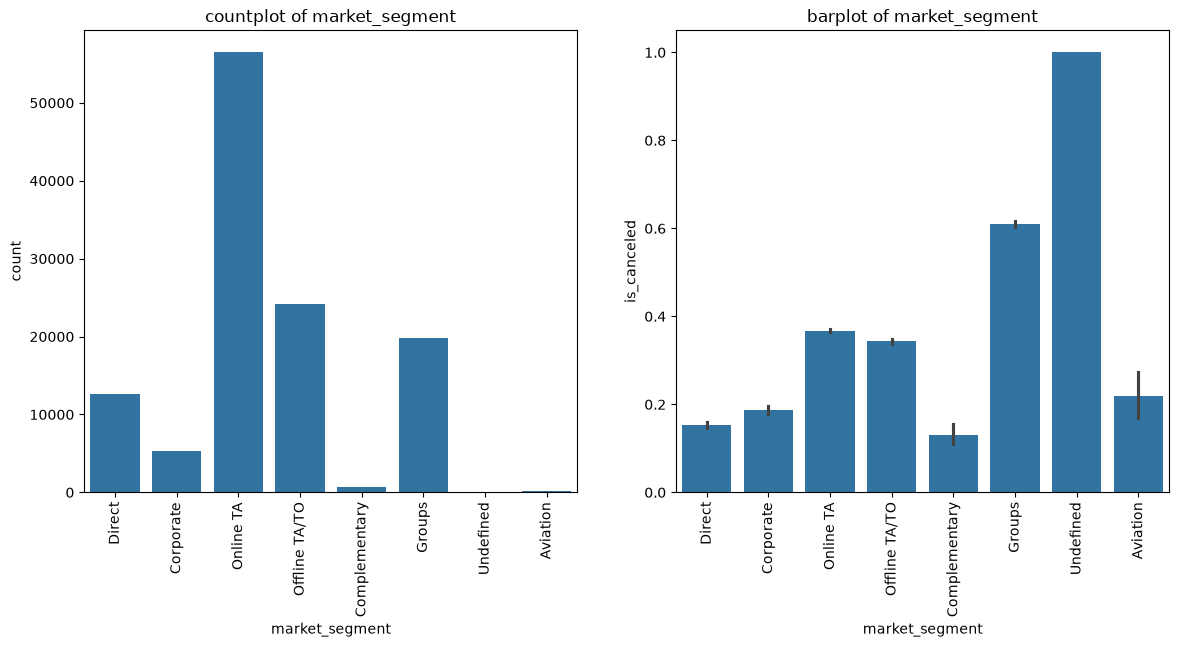

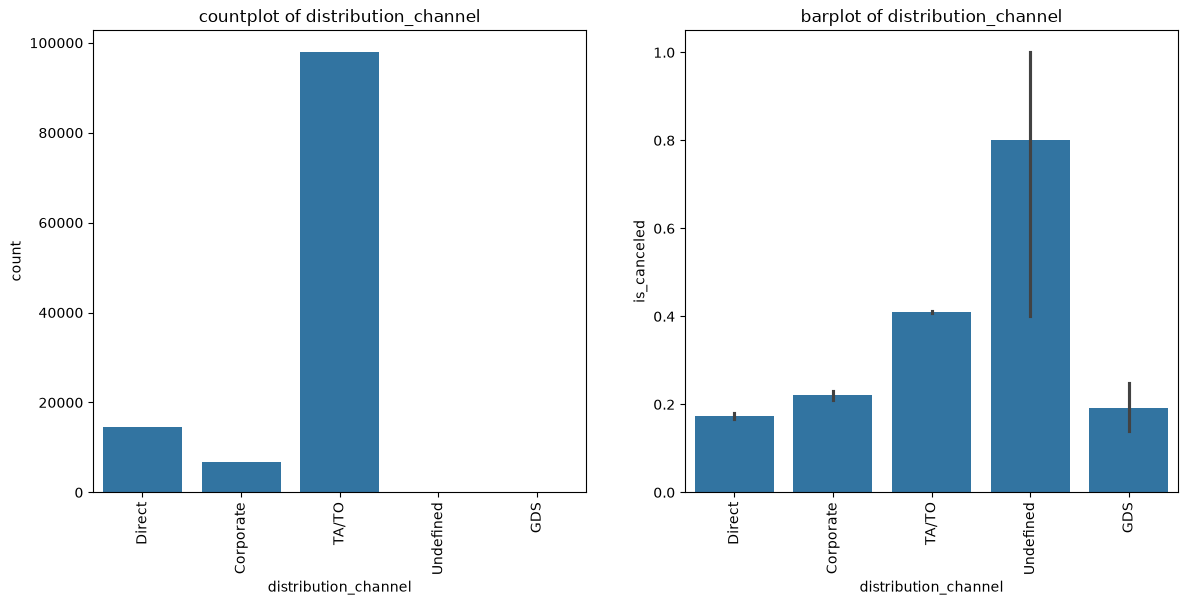

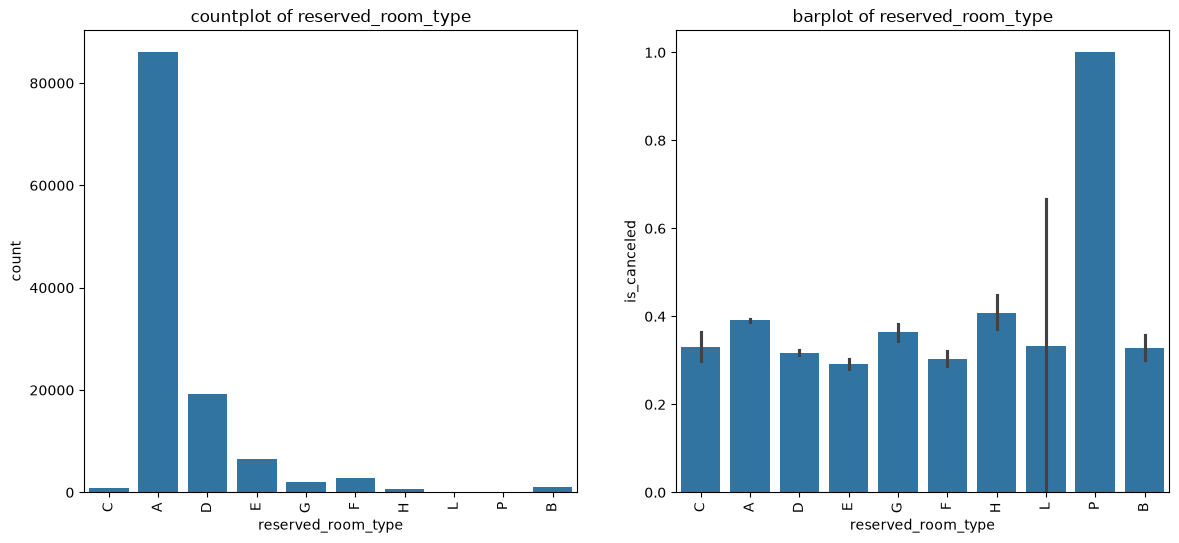

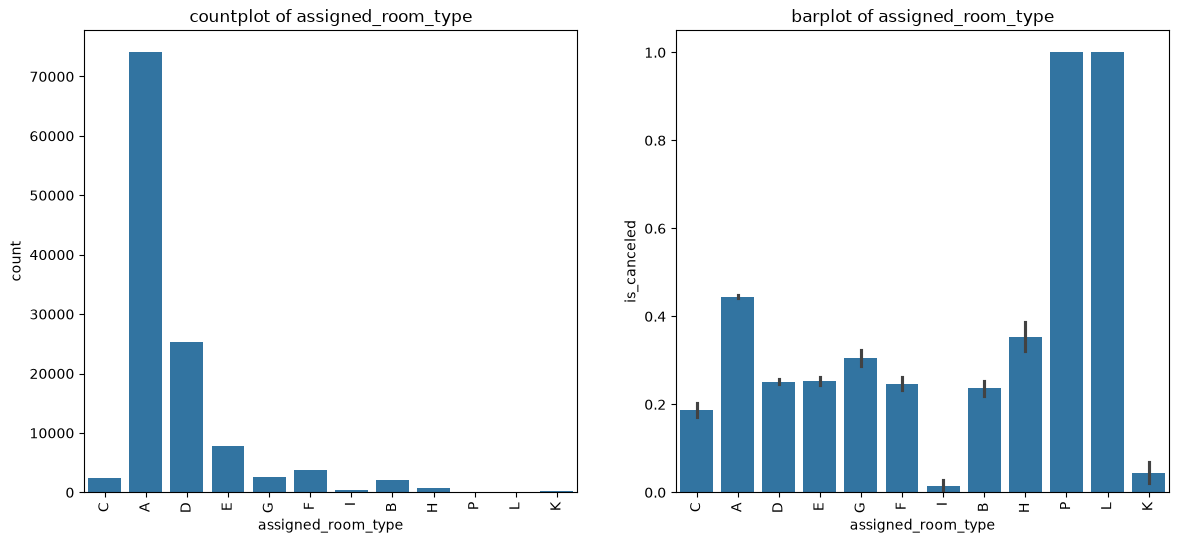

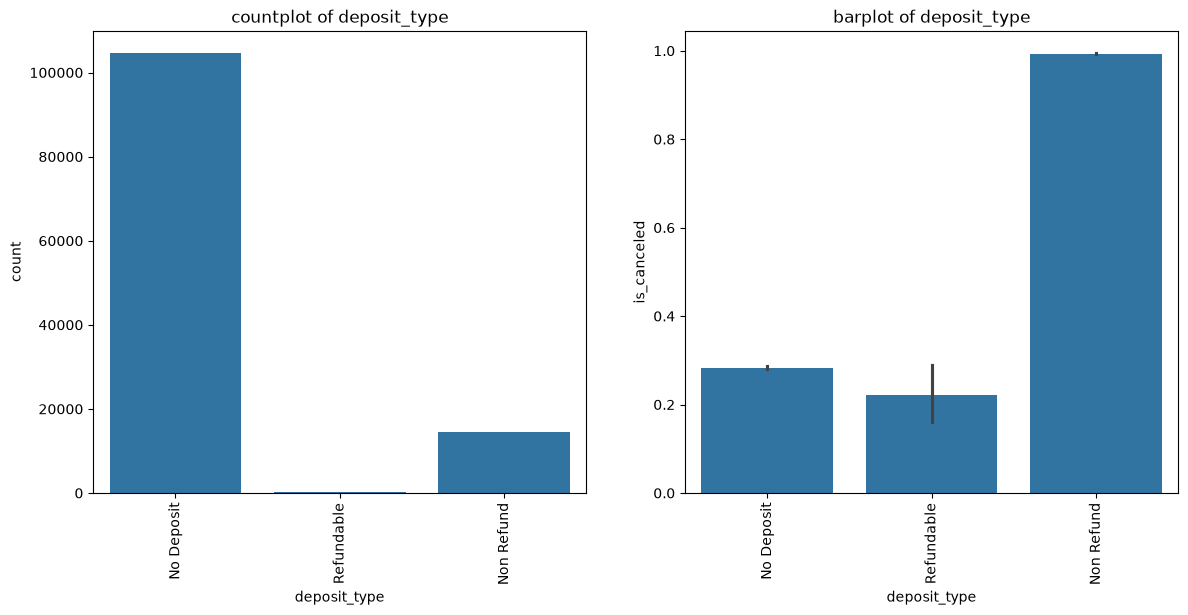

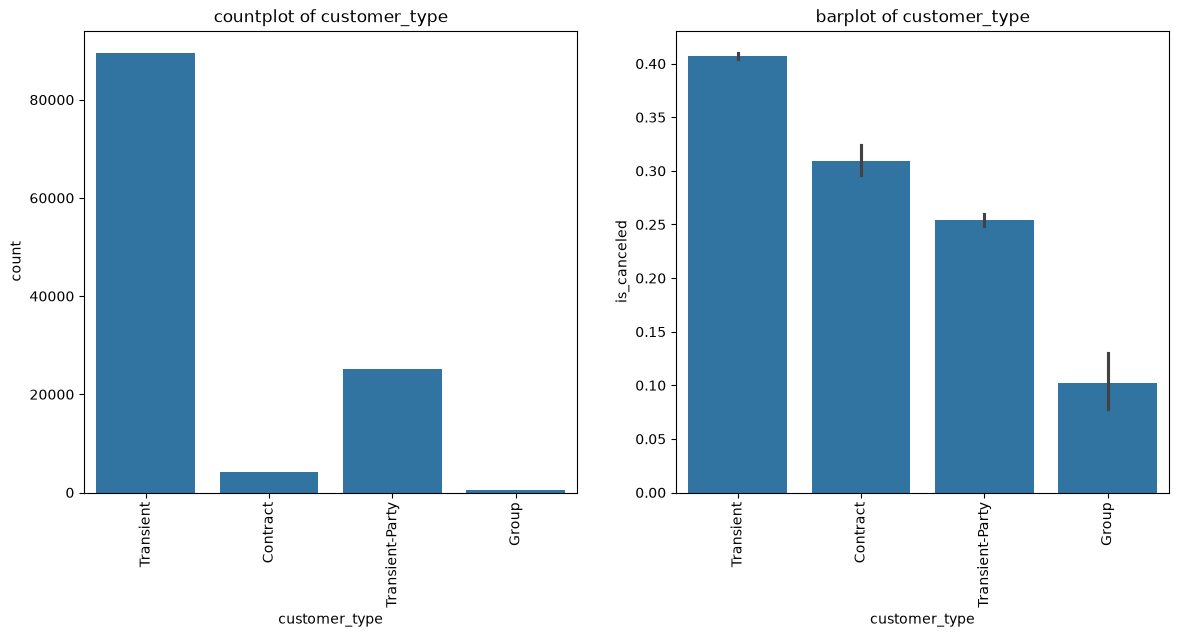

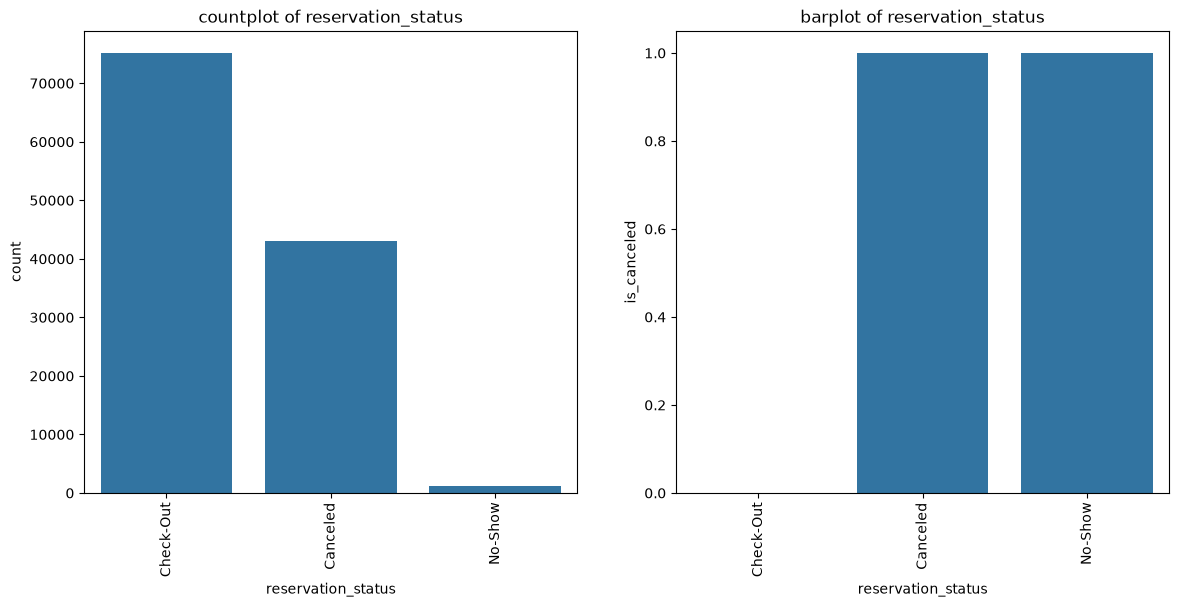

In [15]:
# plots on categorical data 
exclude_cols = ['country' , 'reservation_status_date']
cat_cols = [col for col in cat_columns if col not in exclude_cols]
for col in cat_cols :
    fig , axes = plt.subplots(1,2,figsize=(14,6))
    sns.countplot(data = hotel_data , x = col , ax = axes[0])
    axes[0].set_title(f'countplot of {col}')
    axes[0].tick_params(axis='x', rotation=90)

    sns.barplot(data = hotel_data , x = col , y='is_canceled' , ax = axes[1])
    axes[1].set_title(f'barplot of {col}')
    axes[1].tick_params(axis='x', rotation=90)

    plt.show()

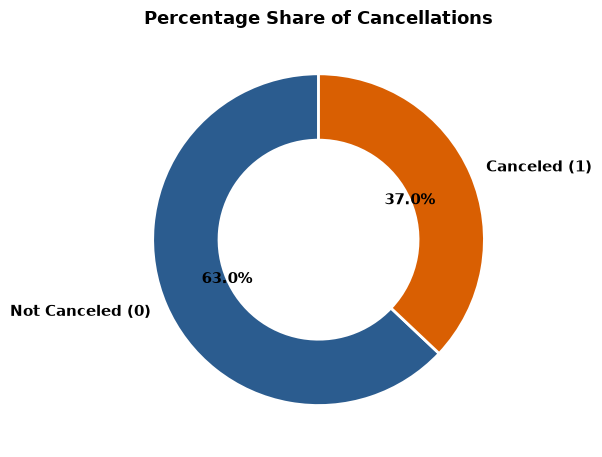

In [16]:
# target variable analysis
# 1. pie chart / donut of cancel percentage

plt.figure(figsize=(6, 6))

counts = hotel_data['is_canceled'].value_counts()
labels = ['Not Canceled (0)', 'Canceled (1)']
colors = ['#2b5c8f', '#d95f02']

plt.pie(
    counts, 
    labels=labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors, 
    wedgeprops={'width': 0.4, 'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.title('Percentage Share of Cancellations', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

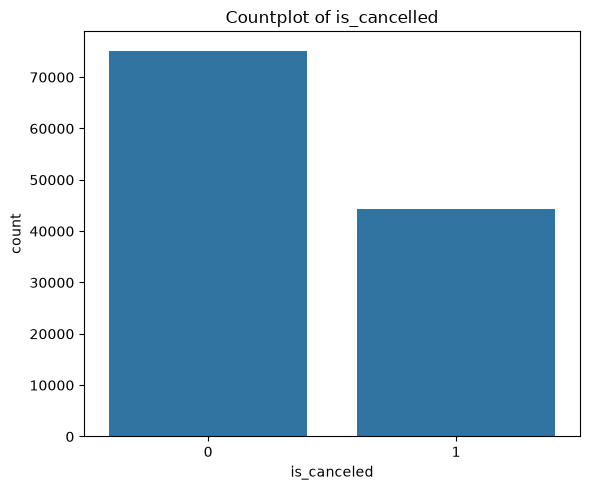

In [17]:
# countplot of cancelation
figure = plt.figure(figsize=(6,5))
sns.countplot(data = hotel_data , x = 'is_canceled')


plt.title('Countplot of is_cancelled')
plt.tight_layout()
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_5496\1654838335.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5496\1654838335.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 0].set_xticklabels(['Not Canceled (0)', 'Canceled (1)'])
C:\Users\lenovo\AppData\Local\Temp\ipykernel_5496\1654838335.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5496\1654838335.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0, 1].set_xticklabels(['Not Canceled (0)', 'Canceled (1)'])


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5496\1654838335.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 0].set_xticklabels(['Not Canceled (0)', 'Canceled (1)'])


C:\Users\lenovo\AppData\Local\Temp\ipykernel_5496\1654838335.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 1].set_xticklabels(['Not Canceled (0)', 'Canceled (1)'])


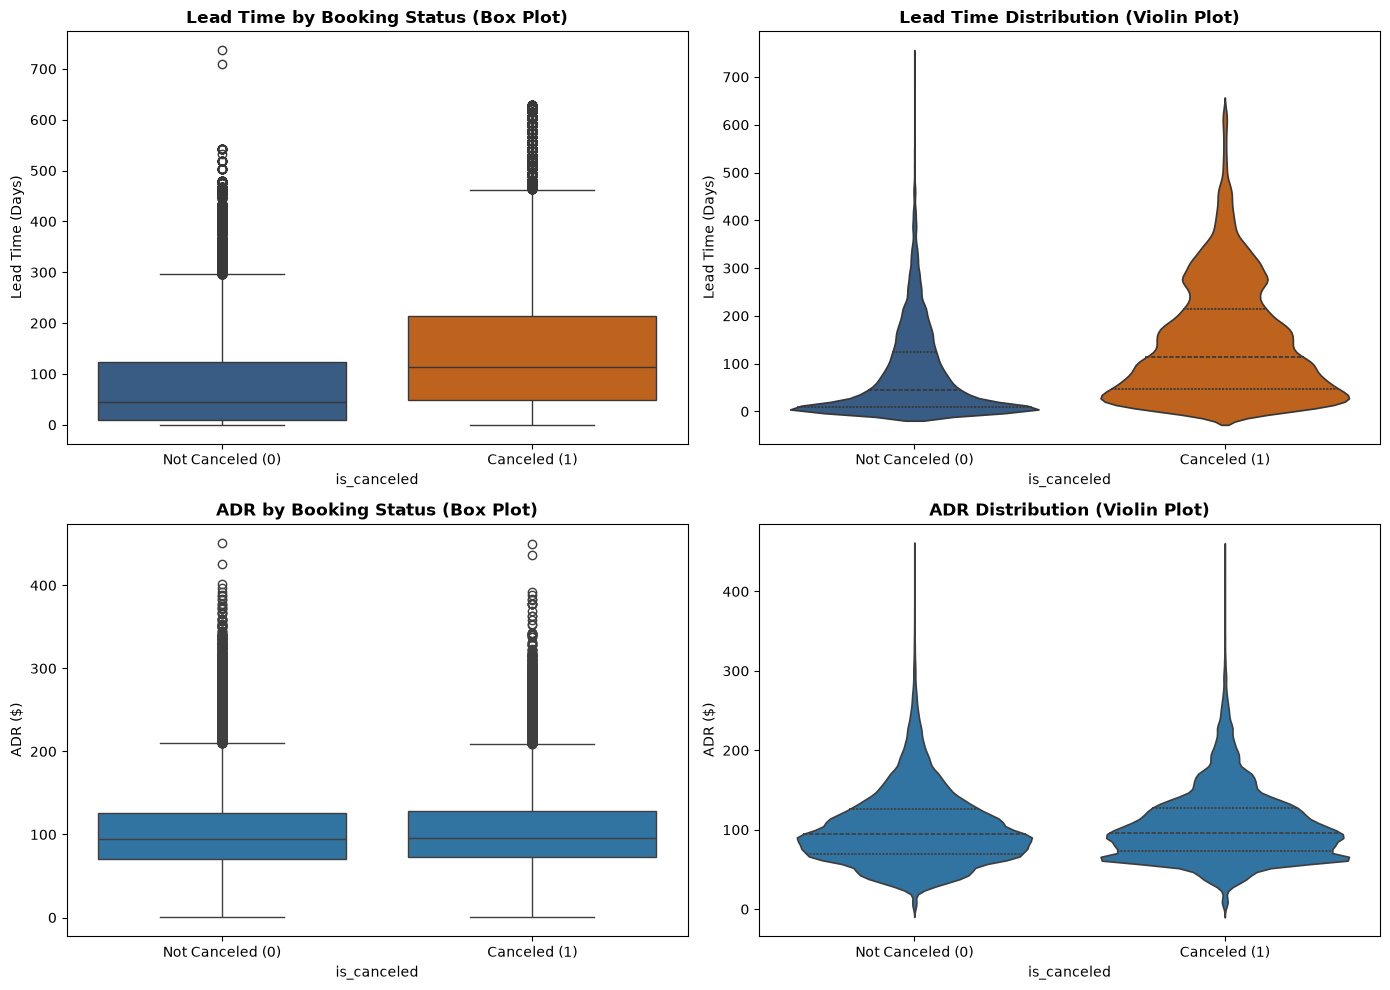

In [18]:
# numerical v/s target charts
# Create a 2x2 grid for Box Plots and Violin Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))


# Box Plot
sns.boxplot(
    data=hotel_data, 
    x='is_canceled', 
    y='lead_time', 
    palette=['#2b5c8f', '#d95f02'], 
    ax=axes[0, 0]
)
axes[0, 0].set_title('Lead Time by Booking Status (Box Plot)', fontweight='bold')
axes[0, 0].set_xticklabels(['Not Canceled (0)', 'Canceled (1)'])
axes[0, 0].set_ylabel('Lead Time (Days)')

# Violin Plot
sns.violinplot(
    data=hotel_data, 
    x='is_canceled', 
    y='lead_time', 
    palette=['#2b5c8f', '#d95f02'], 
    inner='quartile', 
    ax=axes[0, 1]
)
axes[0, 1].set_title('Lead Time Distribution (Violin Plot)', fontweight='bold')
axes[0, 1].set_xticklabels(['Not Canceled (0)', 'Canceled (1)'])
axes[0, 1].set_ylabel('Lead Time (Days)')


# 2. ADR vs is_canceled (Filtered < $500 for clean view)

# Filtering extreme outlier ($5,400) for visual clarity
df_adr_clean = hotel_data[(hotel_data['adr'] > 0) & (hotel_data['adr'] < 500)]

# Box Plot
sns.boxplot(
    data=df_adr_clean, 
    x='is_canceled', 
    y='adr',
    ax=axes[1, 0]
)
axes[1, 0].set_title('ADR by Booking Status (Box Plot)', fontweight='bold')
axes[1, 0].set_xticklabels(['Not Canceled (0)', 'Canceled (1)'])
axes[1, 0].set_ylabel('ADR ($)')

# Violin Plot
sns.violinplot(
    data=df_adr_clean, 
    x='is_canceled', 
    y='adr',  
    inner='quartile', 
    ax=axes[1, 1]
)
axes[1, 1].set_title('ADR Distribution (Violin Plot)', fontweight='bold')
axes[1, 1].set_xticklabels(['Not Canceled (0)', 'Canceled (1)'])
axes[1, 1].set_ylabel('ADR ($)')

plt.tight_layout()
plt.show()

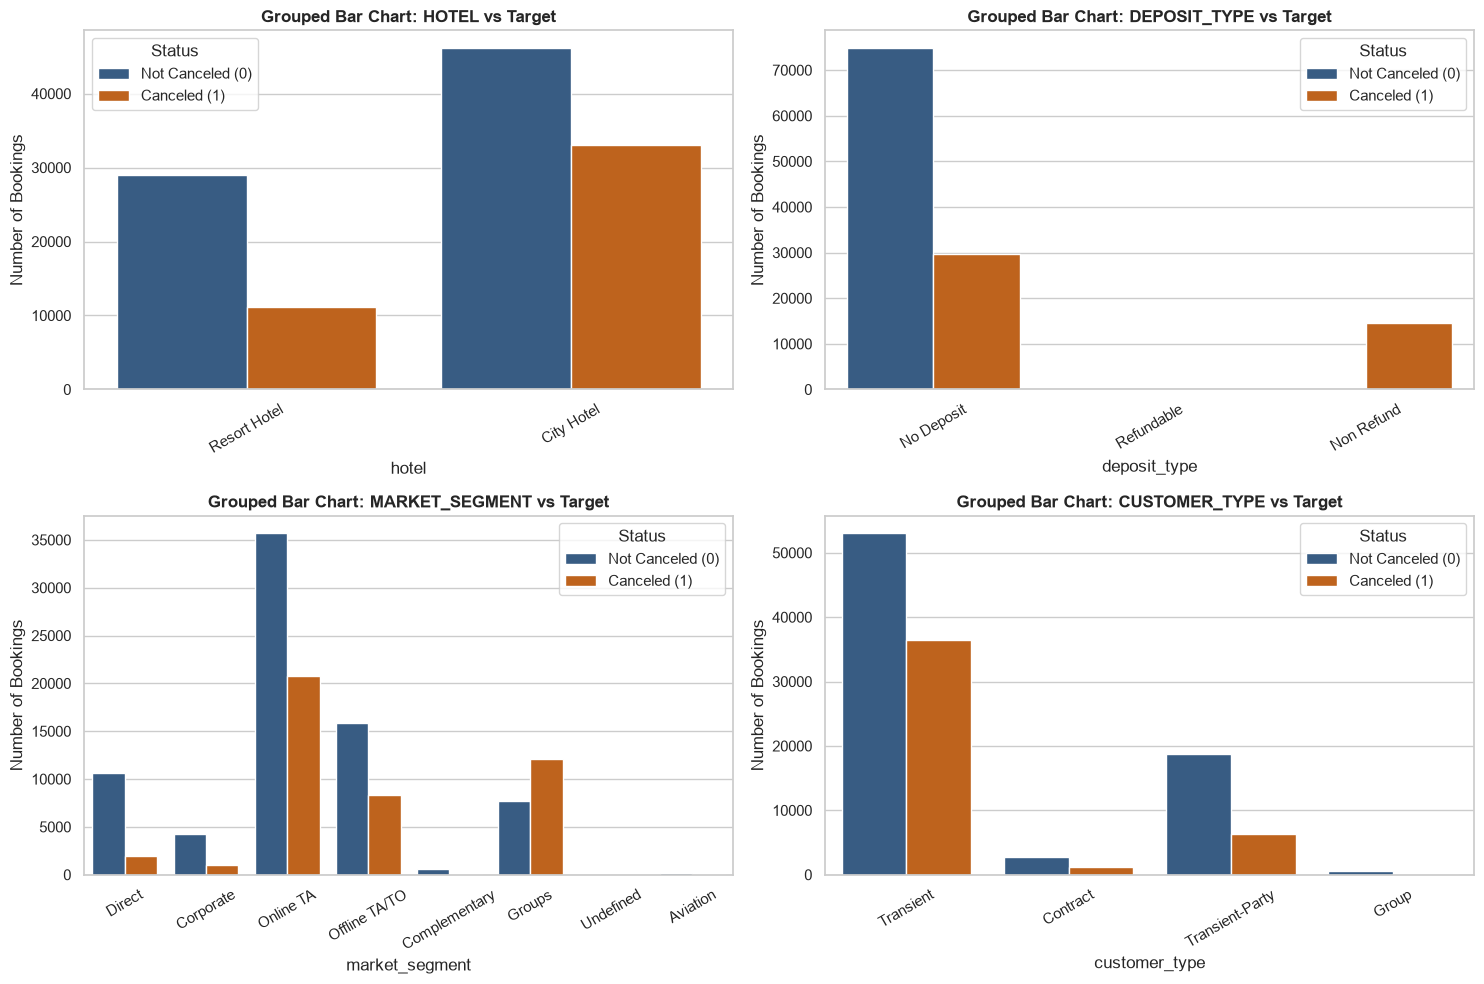

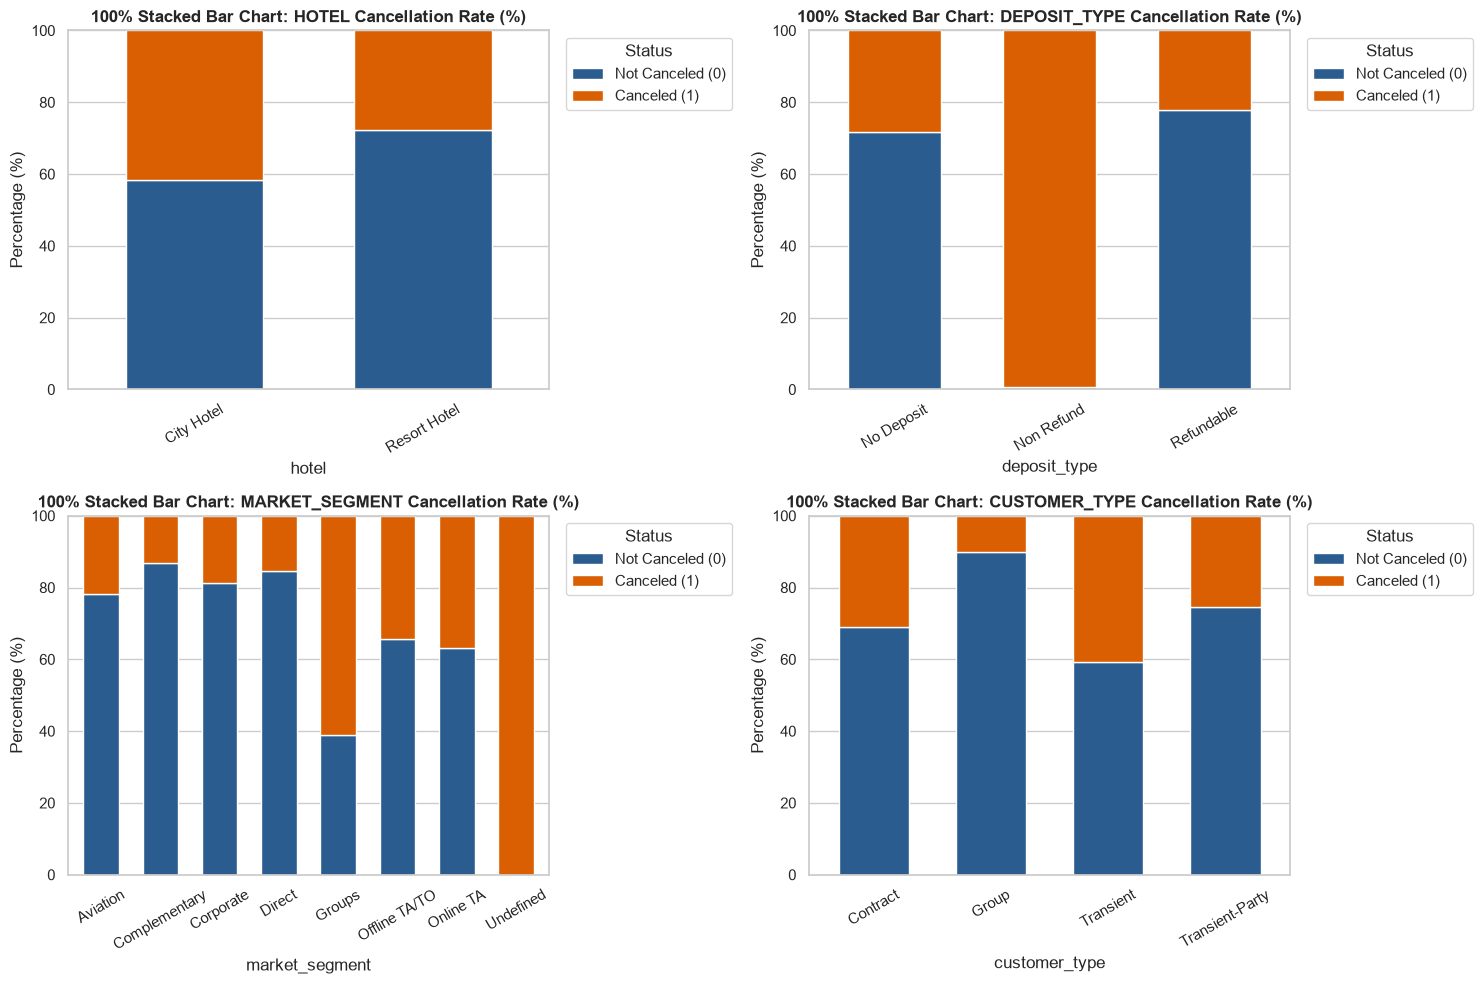

In [19]:
# categorical v/s target
sns.set_theme(style="whitegrid")

# Select key categorical features to compare against target
features = ['hotel', 'deposit_type', 'market_segment', 'customer_type']

# -------------------------------------------------------------
# 1. GROUPED BAR CHARTS (Raw Counts Split by is_canceled)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.countplot(
        data=hotel_data,
        x=col,
        hue='is_canceled',
        palette=['#2b5c8f', '#d95f02'],
        ax=axes[i]
    )
    axes[i].set_title(f'Grouped Bar Chart: {col.upper()} vs Target', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Number of Bookings')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Not Canceled (0)', 'Canceled (1)'], title='Status')

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# 2. 100% STACKED BAR CHARTS (Proportion & Cancellation Rate %)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    # Calculate percentage proportions
    props = pd.crosstab(hotel_data[col], hotel_data['is_canceled'], normalize='index') * 100
    
    # Plot stacked bar chart
    props.plot(
        kind='bar',
        stacked=True,
        color=['#2b5c8f', '#d95f02'],
        ax=axes[i],
        width=0.6
    )
    axes[i].set_title(f'100% Stacked Bar Chart: {col.upper()} Cancellation Rate (%)', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['Not Canceled (0)', 'Canceled (1)'], title='Status', bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

## Summary of EDA Findings & Modeling Hypotheses

### Data Quality
* **Missing Values:** Identified in `children`, `country`, `agent`, and `company`. High missingness in `company` requires dropping or creating `has_company` flag.
* **Duplicate Records:** Kept during EDA to preserve transaction history; audited prior to split.
* **Incorrect Data Types:** Converted binary indicators (`is_canceled`, `is_repeated_guest`) and date strings (`reservation_status_date`).
* **Zero guests :** There are zero guests in some row .Therefore we need to remove that as well . Concluded during checking the .describe()
    for numerical values (min of adults , children , babies = 0 , means 0 guest)

### Numerical Features
* **Skewed Variables:** Extreme positive skew in `lead_time`, `adr`, and stay duration metrics.
* **Outliers:** Severe extreme outliers identified (`adr` at $5,400.00; `required_car_parking_spaces` at 8).
* **Candidate Transformations:** Log transformation ($\log(x+1)$) or robust scaling for skewed metrics.

### Categorical Features
* **Rare Categories:** `country` contains 100+ rare codes (<1% frequency); `deposit_type` has `Refundable` (<0.2%).
* **High-Cardinality Features:** `country` and `reservation_status_date` require special encoding or grouping.

### Target Variable (`is_canceled`)
* **Class Imbalance:** Moderately Imbalanced (~63% Not Canceled vs ~37% Canceled).

### Preprocessing Roadmap
1. **Imputation:** Median for continuous features; `'Unknown'` label for categorical strings.
2. **Encoding:** One-Hot Encoding for low-cardinality features; Target/Frequency encoding for `country`.
3. **Scaling:** `StandardScaler` / `RobustScaler` applied inside Scikit-learn Pipeline.
4. **Feature Engineering:** `total_stay_nights`, `total_guests`, and `is_family` flags.